In [ ]:
import sys
sys.path.append("../")
import importlib
from functools import partial

import matplotlib.pyplot as plt
from IPython.display import display
import pandas as pd 

import torch
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_networkx

In [21]:
config = {
    "DATASET_NAME": "PROTEINS", 
    "device": "cuda",
    "explainee": {
        "epochs": 10, 
        "batch_size": 32, 
        "lr": 1e-3
    }, 
    "ged_model": {
        "n_perds": 4, 
        "epochs": 10, 
        "batch_size": 32, 
    }, 
    "tune": {
        "n_trials": 5, 
        "max_nodes": 10, 
        "iters_per_sample": 20, 
        "samples_per_trial": 2, # Note: per class. 
    },
    "train": {
        "iters_per_sample": 20, 
        "samples_per_trial": 2, # Note: per class. 
    }
}

# Data

In [8]:
import new_src.dataAdapter
from new_src.dataAdapter import load_dataset
importlib.reload(new_src.dataAdapter)

data = load_dataset(config.get("DATASET_NAME"))
cls_split = data.split_by_class()

# Explainee

In [9]:
import new_src.explainee
from new_src.explainee import fit_explainee
importlib.reload(new_src.explainee)

explainee, _ = fit_explainee(
    dataset_name = config.get("DATASET_NAME"),
    root="data",
    hidden=64,
    layers=3,
    dropout=0.2,
    epochs=config["explainee"]["epochs"],
    batch_size=config["explainee"]["batch_size"],
    lr=config["explainee"]["lr"],
    device=config.get("device")
)


# Extract embeddings. 
mean_embeds = [
    torch.cat([explainee(batch.to(config.get("device")))["embeds"]
               for batch in DataLoader(subset, batch_size=64)])
         .mean(dim=0)
    for subset in cls_split
]
mean_embeds = [m.detach() for m in mean_embeds]

[001/10] train_loss=0.6147  val_acc=0.676
[002/10] train_loss=0.5840  val_acc=0.721
[003/10] train_loss=0.5702  val_acc=0.766
[004/10] train_loss=0.5514  val_acc=0.811
[005/10] train_loss=0.5564  val_acc=0.784
[006/10] train_loss=0.5492  val_acc=0.784
[007/10] train_loss=0.5468  val_acc=0.793
[008/10] train_loss=0.5398  val_acc=0.757
[009/10] train_loss=0.5484  val_acc=0.766
[010/10] train_loss=0.5416  val_acc=0.721
Test Accuracy: 0.741


# GED Approximator

Generating synthetic GED dataset with 4 perturbations per graph...
Created GED dataset with 4452 pairs.


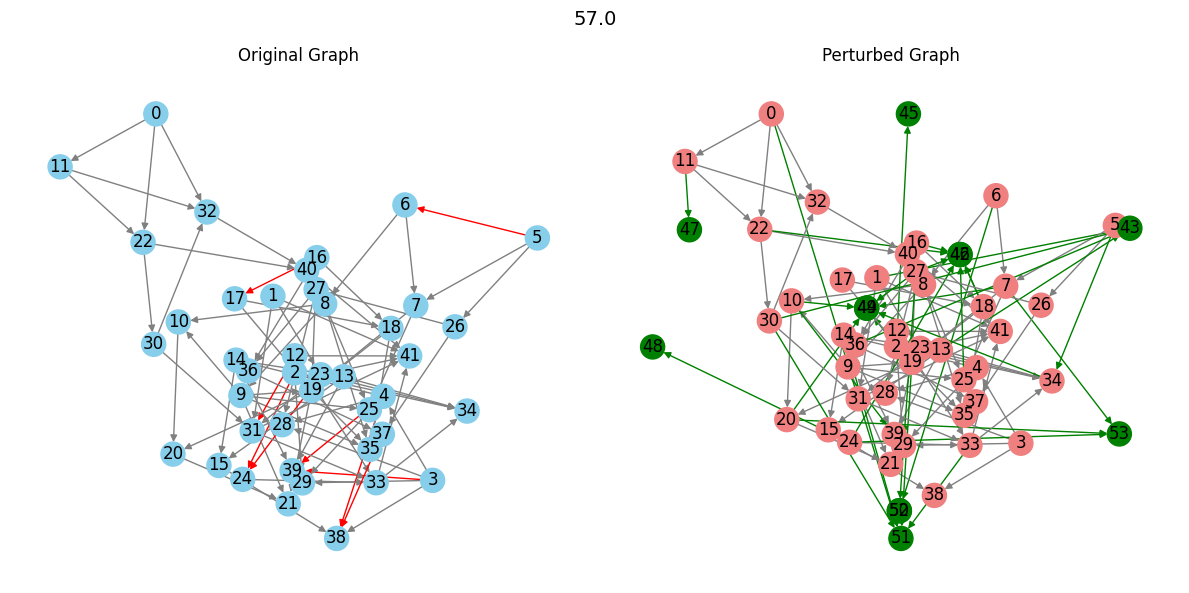

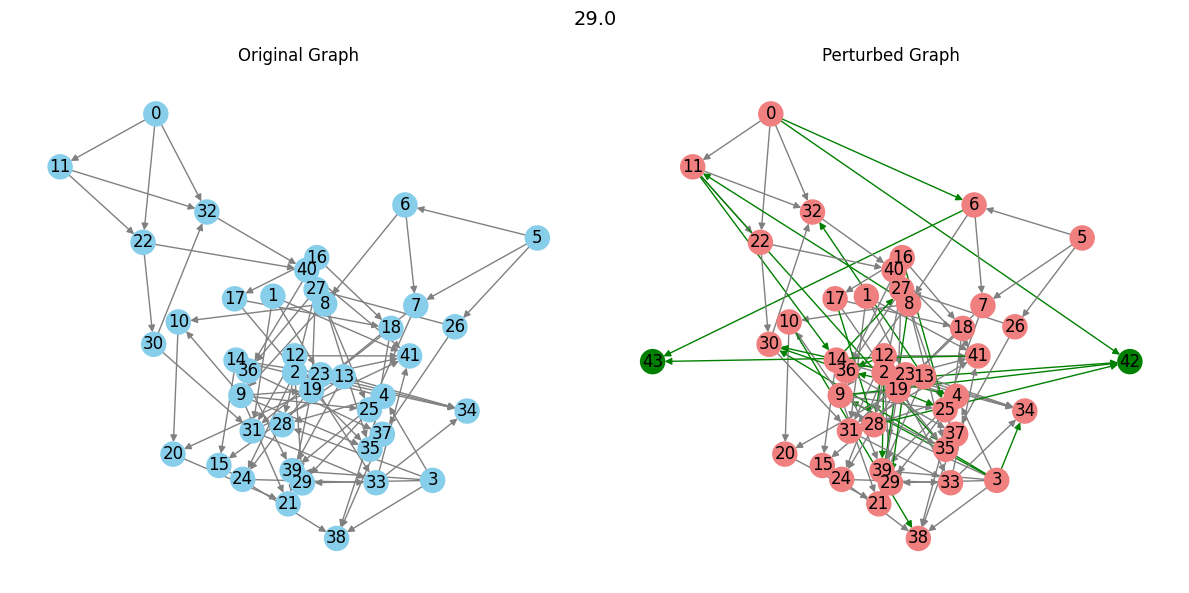

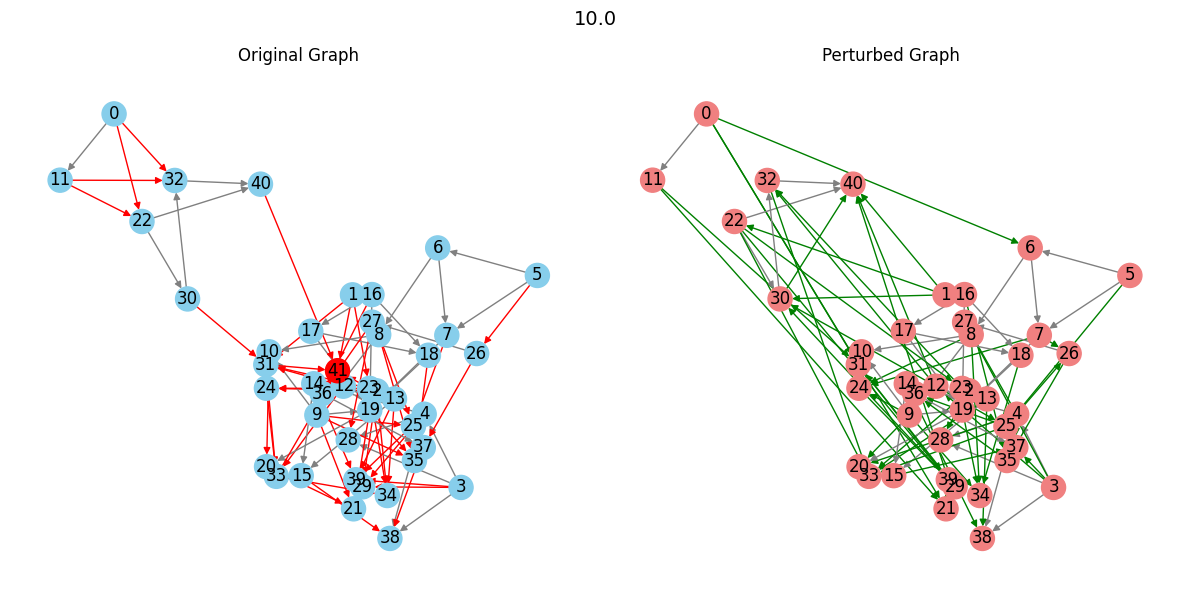

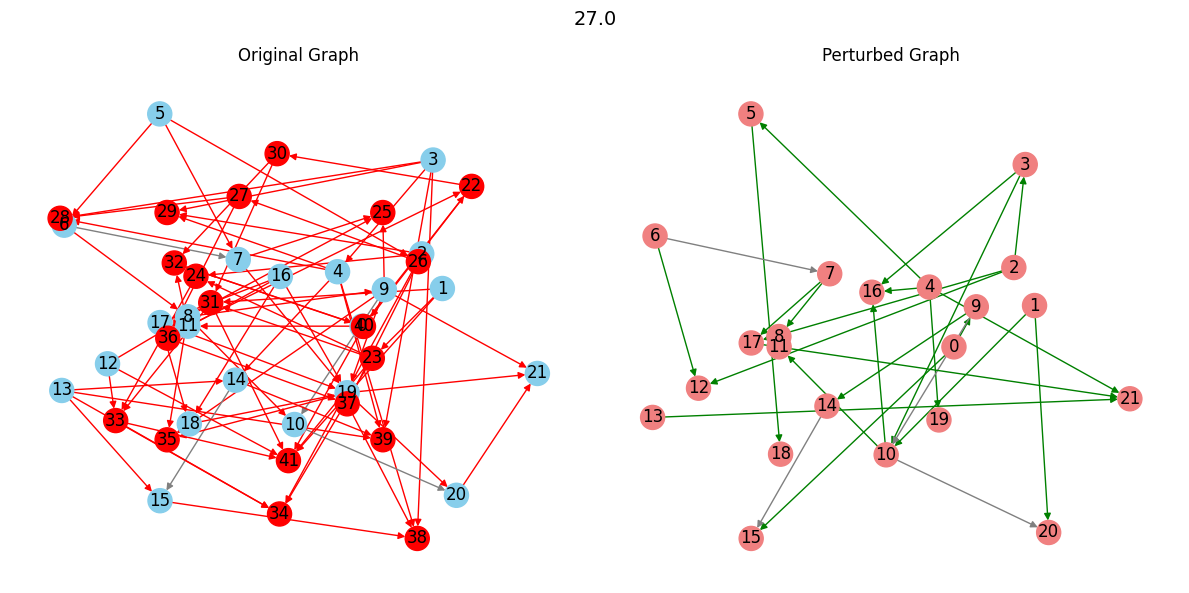

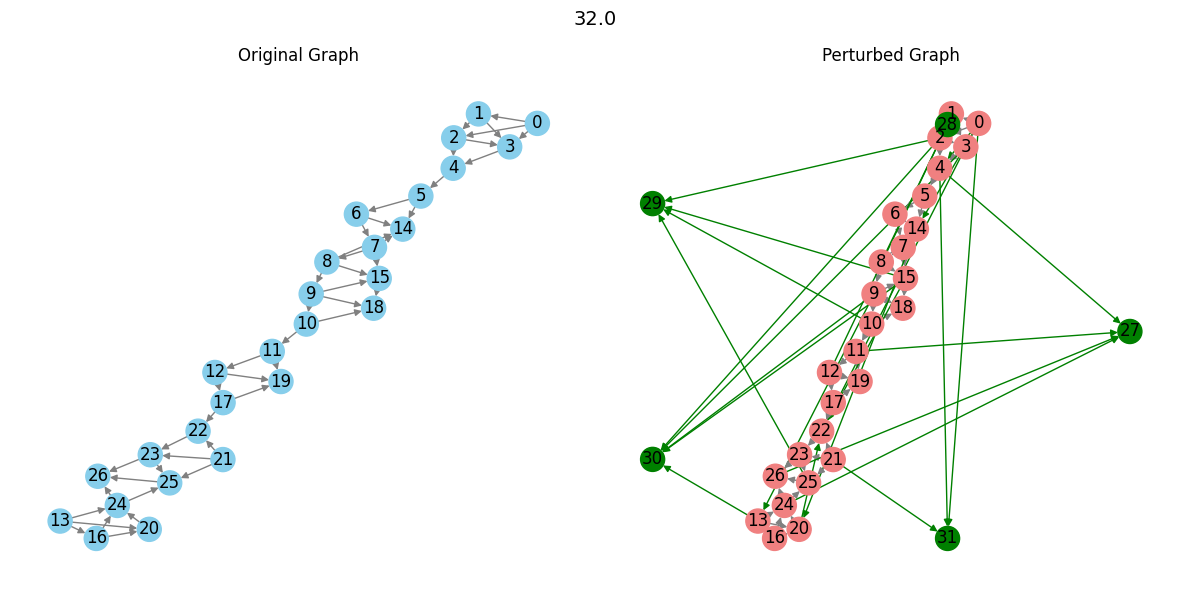

In [11]:
import new_src.ged_dataset
importlib.reload(new_src.ged_dataset)

from new_src.ged_dataset import create_and_save_ged_dataset, plot_graph_pair

ged_dataset = create_and_save_ged_dataset(
    data, 
    out_path=None, 
    n_perturbations=config["ged_model"]["n_perds"],
    node_add_prob=0.5,
    node_remove_prob=0.5,
    edge_add_prob=0.1, 
    edge_remove_prob=0.1
)

print(f"Created GED dataset with {len(ged_dataset)} pairs.")

for i in range(5):
    g1, g2, ged_norm, _, _ = ged_dataset[i]
    raw_ged = getattr(g1, "raw_ged", ged_norm)
    plot_graph_pair(g1, g2, label=raw_ged)

In [12]:
import new_src.simgnn
importlib.reload(new_src.simgnn)

from new_src.simgnn import SimGNN, train_simgnn

model = SimGNN(in_dim=len(data.NODE_CLS))

train_simgnn(
    model=(m := model), 
    data=ged_dataset, 
    batch_size=config["ged_model"]["batch_size"], 
    optimizer=(o := torch.optim.Adam(m.parameters(), lr=1e-3)),
    scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
    epochs=config["ged_model"]["epochs"], 
    device=config.get("device")
)

Training SimGNN:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 001 | Loss: 232.1614 | MSE(norm): 232.1614 | MSE(raw): 337386560.0000 | Corr(norm): 0.0110 | Corr(raw): 0.1060
Epoch 002 | Loss: 21.8025 | MSE(norm): 21.8025 | MSE(raw): 30656880.0000 | Corr(norm): 0.0473 | Corr(raw): 0.1346
Epoch 003 | Loss: 12.6908 | MSE(norm): 12.6908 | MSE(raw): 17940218.0000 | Corr(norm): -0.0401 | Corr(raw): -0.2570
Epoch 004 | Loss: 3.4590 | MSE(norm): 3.4590 | MSE(raw): 8067307.5000 | Corr(norm): 0.0419 | Corr(raw): 0.0786
Epoch 005 | Loss: 2.6226 | MSE(norm): 2.6226 | MSE(raw): 7065978.5000 | Corr(norm): -0.0301 | Corr(raw): -0.0005
Epoch 006 | Loss: 1.0509 | MSE(norm): 1.0509 | MSE(raw): 1756184.2500 | Corr(norm): 0.0101 | Corr(raw): 0.2194
Epoch 007 | Loss: 0.8691 | MSE(norm): 0.8691 | MSE(raw): 1195084.0000 | Corr(norm): -0.0306 | Corr(raw): -0.1344
Epoch 008 | Loss: 0.5806 | MSE(norm): 0.5806 | MSE(raw): 649965.6250 | Corr(norm): -0.0365 | Corr(raw): -0.4196
Epoch 009 | Loss: 0.5960 | MSE(norm): 0.5960 | MSE(raw): 1039648.1250 | Corr(norm): 0.0426 | 

# Generator

In [13]:
# All passes should be explicit. 
def train_generator(
    cls_idx, 
    max_nodes, 
    iters_per_sample, 
    data, 
    mean_embeds, 
    explainee, 
    ged_model, 
    w_pred=1,
    w_embed=1,
    w_ged=1,
    w_mcs=1,
    w_spec=1,
    w_wl=1,
    use_omega=False,  
):

    from new_src.graph_sampler import GraphSampler
    from new_src.trainer import Trainer
    from new_src.criteria import (
        WeightedCriterion, 
        ClassScoreCriterion, 
        EmbeddingCriterion, 
        BudgetPenalty
    )
    
    from new_src.graph_level_dist import (
        neural_approx_ged_dist, 
        mcs_soft_graph_dist, 
        spectral_dist, 
        wl_graph_kernel_dist
    )
    
    trainer = Trainer(
        sampler=(
            s := GraphSampler(
                    max_nodes=max_nodes,
                    num_node_cls=len(data.NODE_CLS),
                    num_edge_cls=len(data.EDGE_CLS), 
                    temperature=0.15,
                    learn_node_feat=len(data.NODE_CLS) > 0, 
                    learn_edge_feat=len(data.EDGE_CLS) > 0, 
            )
        ),
        discriminator=explainee,
        criterion=WeightedCriterion([
            dict(key="logits", 
                criterion=ClassScoreCriterion(
                    class_idx=cls_idx, mode='maximize'
                ), 
                weight=w_pred
            ),
            dict(key="embeds", 
                criterion=EmbeddingCriterion(
                    target_embedding=mean_embeds[cls_idx]
                ), 
                weight=w_embed
            ),
            dict(key="cont_data", 
                criterion=neural_approx_ged_dist(
                    data = data, model = ged_model, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_ged
            ), 
            dict(key="cont_data", 
                criterion=mcs_soft_graph_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_mcs
            ), 
            dict(key="cont_data", 
                criterion=spectral_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_spec
            ), 
            dict(key="cont_data", 
                criterion=wl_graph_kernel_dist(
                    data = data, explainee=explainee, 
                    cls_idx=cls_idx, 
                    use_omega=use_omega
                ), 
                weight=w_wl
            ), 
        ]),
        optimizer=(o := torch.optim.SGD(s.parameters(), lr=1)),
        scheduler=torch.optim.lr_scheduler.ExponentialLR(o, gamma=1),
        dataset=data,
        budget_penalty=BudgetPenalty(budget=20, order=2, beta=1),
        device=config.get("device")
    )

    trainer.train(
        iterations=iters_per_sample,
        target_probs={cls_idx: (0.9, 1.0)},
        target_size=30,
        w_budget_init=0.5,
        w_budget_inc=1.1,
        w_budget_dec=0.95,
        k_samples=32
    )

    example = trainer.evaluate(threshold=0.5)

    example = from_networkx(example)

    if "label" in example: 
        example.x = F.one_hot(
            example.label, num_classes=len(data.NODE_CLS)
        ).float()

    if "edge_label" in example: 
        example.edge_attr = F.one_hot(
            example.edge_label, num_classes=len(data.EDGE_CLS)
        ).float()

    example.y = torch.tensor(cls_idx).float()
    
    return example

## Tuning

In [14]:
import ray
from ray import tune
from ray import air
from ray.tune import ExperimentAnalysis
ray.shutdown()
ray.init(
    runtime_env={
        "py_modules": ["/repo/revisions/new_src"]
    },
    num_gpus=1
)

data_ref = ray.put(data)
mean_embeds_ref = ray.put(mean_embeds)
cls_split_ref = ray.put(data.split_by_class())

2025-11-11 20:02:13,492	WARNING services.py:2155 -- WARNING: The object store is using /tmp instead of /dev/shm because /dev/shm has only 67104768 bytes available. This will harm performance! You may be able to free up space by deleting files in /dev/shm. If you are inside a Docker container, you can increase /dev/shm size by passing '--shm-size=10.24gb' to 'docker run' (or add it to the run_options list in a Ray cluster config). Make sure to set this to more than 30% of available RAM.
2025-11-11 20:02:13,717	INFO worker.py:2012 -- Started a local Ray instance.
2025-11-11 20:02:14,029	INFO packaging.py:588 -- Creating a file package for local module '/repo/revisions/new_src'.
2025-11-11 20:02:14,525	INFO packaging.py:380 -- Pushing file package 'gcs://_ray_pkg_f4ac3dca869131c1.zip' (0.38MiB) to Ray cluster...
2025-11-11 20:02:14,529	INFO packaging.py:393 -- Successfully pushed file package 'gcs://_ray_pkg_f4ac3dca869131c1.zip'.
/opt/venv/lib/python3.12/site-packages/ray/_private/worker

In [15]:
def tune_generator(
    config, *,
    explainee, 
    model, 
    max_nodes, 
    gen_samples, 
    iters_per_sample, 
):
    from new_src.eval import eval_summary
    from new_src.graph_level_dist import neural_approx_ged_dist

    data = ray.get(data_ref) 
    mean_embeds = ray.get(mean_embeds_ref)
    cls_split = ray.get(cls_split_ref)
   
    w_pred  = float(config["pred_weight"])
    w_embed = float(config["embed_weight"])
    w_ged   = float(config["ged_weight"])
    w_mcs   = float(config["mcs_weight"])
    w_spec  = float(config["spectral_weight"])
    w_wl    = float(config["wl_weight"])
    use_omega = bool(config["use_omega"])
    
    graphs_0 = [
        train_generator(
            cls_idx=0, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 

    graphs_1 = [
        train_generator(
            cls_idx=1, 
            max_nodes=max_nodes, 
            iters_per_sample=iters_per_sample, 
            data=data, 
            explainee=explainee, 
            mean_embeds=mean_embeds, 
            ged_model=model, 
            w_pred=w_pred, 
            w_embed=w_embed, 
            w_ged=w_ged, 
            w_mcs=w_mcs, 
            w_spec=w_spec, 
            w_wl=w_wl, 
            use_omega = use_omega
        ) 
        for _ in range(gen_samples)
    ] 
    
    dist_to_0 = neural_approx_ged_dist(cls_split[0], model)
    dist_to_1 = neural_approx_ged_dist(cls_split[1], model)
     
    score = eval_summary(
        explainee, graphs_0, graphs_1,
        cls_split[0], cls_split[1], 
        dist_to_0, dist_to_1
    ) 
    
    results = {
        "score": float(score)
    }

    tune.report(results)

    return results

In [22]:
search_space = {
    "pred_weight": tune.uniform(0, 50),
    "embed_weight": tune.uniform(0, 50),
    "ged_weight": tune.uniform(0, 50),
    "mcs_weight": tune.uniform(0, 50),
    "spectral_weight": tune.uniform(0, 50),
    "wl_weight": tune.uniform(0, 50),
    "use_omega": tune.choice([True, False])
}

trainable = tune.with_parameters(
    tune_generator, 
    explainee=explainee,
    model=model, 
    max_nodes=config["tune"]["max_nodes"],
    gen_samples=config["tune"]["samples_per_trial"], 
    iters_per_sample=config["tune"]["iters_per_sample"]
)

gen_tuner = tune.Tuner(
    trainable=tune.with_resources(
        trainable, 
        resources={"gpu": 1}
    ), 
    param_space=search_space,
    tune_config=tune.TuneConfig(
        num_samples=config["tune"]["n_trials"],  
        metric="score",
        mode="max"
    ), 
)

In [ ]:
tune_results = gen_tuner.fit()

 30%|███       | 6/20 [00:06<00:12,  1.11it/s, size=19.1, bpw=0.5, non-enzyme=-0.00779, enzyme=0.0658]
(bundle_reservation_check_func pid=50378) [2025-11-11 20:05:18,701 E 50378 50422] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
 60%|██████    | 12/20 [00:11<00:07,  1.14it/s, size=19.3, bpw=0.5, non-enzyme=-0.0391, enzyme=0.0835]
(tune_generator pid=50462) [2025-11-11 20:05:20,768 E 50462 50506] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 20/20 [00:20<00:00,  1.02s/it, size=14.9, bpw=0.5, non-enzyme=-0.257, enzyme=0.259]


(tune_generator pid=50462) Prediction Interval Class 0 0.43747830390930176 +/- 0.021479472517967224
(tune_generator pid=50462) 
(tune_generator pid=50462) Prediction Interval Class 1 0.7189817428588867 +/- 0.03486168384552002
(tune_generator pid=50462) 
(tune_generator pid=50462) Counterfactual Shift to Class 0 0.16322119534015656 +/- 0.04456298053264618
(tune_generator pid=50462) 
(tune_generator pid=50462) Counterfactual Shift to Class 1 -0.0809856429696083 +/- 0.07458522915840149
(tune_generator pid=50462) 
(tune_generator pid=50462) Class 0 Perturbation Sensitivity 0.013314679265022278 +/- 0.01779351942241192
(tune_generator pid=50462) 
(tune_generator pid=50462) Class 1 Perturbation Sensitivity 0.015186118893325329 +/- 0.01178645994514227
(tune_generator pid=50462) 
(tune_generator pid=50462) Relative Distance to Class 0 0.350979208946228 +/- 0.3182406425476074 
(tune_generator pid=50462) 
(tune_generator pid=50462) Relative Distance to Class 1 -0.032163262367248535 +/- 0.07480150

 45%|████▌     | 9/20 [00:08<00:09,  1.18it/s, size=19, bpw=0.5, non-enzyme=-0.0879, enzyme=0.142]  
(tune_generator pid=50739) [2025-11-11 20:07:14,671 E 50739 50783] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 20/20 [00:16<00:00,  1.21it/s, size=17.2, bpw=0.5, non-enzyme=-0.644, enzyme=0.641]


(tune_generator pid=50739) 
(tune_generator pid=50739) 
(tune_generator pid=50739) 
(tune_generator pid=50739) 
(tune_generator pid=50739) 
(tune_generator pid=50739) 
(tune_generator pid=50739) 
(tune_generator pid=50739) 
(tune_generator pid=50739) Prediction Interval Class 1 0.7875140905380249 +/- 0.003801494836807251 [repeated 2x across cluster]
(tune_generator pid=50739) Counterfactual Shift to Class 1 -0.056546881794929504 +/- 0.09130299091339111 [repeated 2x across cluster]
(tune_generator pid=50739) Class 1 Perturbation Sensitivity 0.0024908841587603092 +/- 0.0019105642568320036 [repeated 2x across cluster]
(tune_generator pid=50739) Relative Distance to Class 1 -0.5195841193199158 +/- 0.5748195052146912  [repeated 2x across cluster]


 45%|████▌     | 9/20 [00:11<00:10,  1.08it/s, size=19, bpw=0.5, non-enzyme=-0.0139, enzyme=0.0787] 
(tune_generator pid=51016) [2025-11-11 20:09:10,634 E 51016 51055] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 20/20 [00:20<00:00,  1.02s/it, size=17.6, bpw=0.5, non-enzyme=-0.637, enzyme=0.671]


(tune_generator pid=51016) 
(tune_generator pid=51016) 
(tune_generator pid=51016) 
(tune_generator pid=51016) 
(tune_generator pid=51016) 
(tune_generator pid=51016) 
(tune_generator pid=51016) 
(tune_generator pid=51016) 
(tune_generator pid=51016) Prediction Interval Class 1 0.7942634224891663 +/- 0.006423294544219971 [repeated 2x across cluster]
(tune_generator pid=51016) Counterfactual Shift to Class 1 -0.05870308727025986 +/- 0.1038690060377121 [repeated 2x across cluster]
(tune_generator pid=51016) Class 1 Perturbation Sensitivity 0.0008261442417278886 +/- 0.0008329953998327255 [repeated 2x across cluster]
(tune_generator pid=51016) Relative Distance to Class 1 -0.027912117540836334 +/- 0.09487121552228928  [repeated 2x across cluster]


 50%|█████     | 10/20 [00:09<00:09,  1.06it/s, size=18.4, bpw=0.5, non-enzyme=-0.0533, enzyme=0.0756]
(tune_generator pid=51286) [2025-11-11 20:11:03,407 E 51286 51330] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 20/20 [00:17<00:00,  1.15it/s, size=18.4, bpw=0.5, non-enzyme=-0.676, enzyme=0.694]


(tune_generator pid=51286) 
(tune_generator pid=51286) 
(tune_generator pid=51286) 
(tune_generator pid=51286) 
(tune_generator pid=51286) 
(tune_generator pid=51286) 
(tune_generator pid=51286) 
(tune_generator pid=51286) 
(tune_generator pid=51286) Prediction Interval Class 1 0.7929103374481201 +/- 0.005017369985580444 [repeated 2x across cluster]
(tune_generator pid=51286) Counterfactual Shift to Class 1 -0.05780763924121857 +/- 0.09960362315177917 [repeated 2x across cluster]
(tune_generator pid=51286) Class 1 Perturbation Sensitivity 0.0016256332164630294 +/- 0.0010233970824629068 [repeated 2x across cluster]
(tune_generator pid=51286) Relative Distance to Class 1 -0.07341212034225464 +/- 0.10146692395210266  [repeated 2x across cluster]


 50%|█████     | 10/20 [00:12<00:10,  1.09s/it, size=19, bpw=0.5, non-enzyme=-0.00604, enzyme=0.0465]
(tune_generator pid=51555) [2025-11-11 20:12:58,043 E 51555 51599] core_worker_process.cc:825: Failed to establish connection to the metrics exporter agent. Metrics will not be exported. Exporter agent status: RpcError: Running out of retries to initialize the metrics agent. rpc_code: 14
100%|██████████| 20/20 [00:20<00:00,  1.00s/it, size=18.2, bpw=0.5, non-enzyme=-0.639, enzyme=0.673]
2025-11-11 20:14:15,011	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to '/root/ray_results/tune_generator_2025-11-11_20-04-43' in 0.0042s.
2025-11-11 20:14:15,018	INFO tune.py:1041 -- Total run time: 570.05 seconds (570.00 seconds for the tuning loop).


(tune_generator pid=51555) Prediction Interval Class 0 0.4985009431838989 +/- 0.003242179751396179
(tune_generator pid=51555) 
(tune_generator pid=51555) Prediction Interval Class 1 0.7881169319152832 +/- 0.0010239183902740479
(tune_generator pid=51555) 
(tune_generator pid=51555) Counterfactual Shift to Class 0 0.16450536251068115 +/- 0.057493165135383606
(tune_generator pid=51555) 
(tune_generator pid=51555) Counterfactual Shift to Class 1 -0.05706083029508591 +/- 0.10001382231712341
(tune_generator pid=51555) 
(tune_generator pid=51555) Class 0 Perturbation Sensitivity 0.003417837666347623 +/- 0.003779633203521371
(tune_generator pid=51555) 
(tune_generator pid=51555) Class 1 Perturbation Sensitivity 0.0009057581191882491 +/- 0.0005692042759619653
(tune_generator pid=51555) 
(tune_generator pid=51555) Relative Distance to Class 0 -0.04918500781059265 +/- 0.15611296892166138 
(tune_generator pid=51555) 
(tune_generator pid=51555) Relative Distance to Class 1 -0.030022814869880676 +/-

Best configuration: {'pred_weight': 18.36166405795347, 'embed_weight': 15.48352373952025, 'ged_weight': 35.3422953378682, 'mcs_weight': 15.138586057879088, 'spectral_weight': 27.97498830681085, 'wl_weight': 23.92139307727616, 'use_omega': False}


,score,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,pid,...,time_since_restore,iterations_since_restore,config/pred_weight,config/embed_weight,config/ged_weight,config/mcs_weight,config/spectral_weight,config/wl_weight,config/use_omega,logdir
0,0.891379,1762891599,None,False,2,aae78_00000,2025-11-11_20-06-39,0.000513,106.932726,50462,...,106.932726,2,46.298969,24.033341,29.123428,32.838545,25.817211,43.144048,True,aae78_00000
1,1.787846,1762891715,None,False,2,aae78_00001,2025-11-11_20-08-35,0.000590,109.499388,50739,...,109.499388,2,18.361664,15.483524,35.342295,15.138586,27.974988,23.921393,False,aae78_00001
2,1.388609,1762891828,None,False,2,aae78_00002,2025-11-11_20-10-28,0.000722,106.080600,51016,...,106.080600,2,39.023752,39.826982,40.663541,14.373436,24.771389,20.238731,False,aae78_00002
3,1.442781,1762891943,None,False,2,aae78_00003,2025-11-11_20-12-23,0.000729,108.202414,51286,...,108.202414,2,49.479908,14.934038,34.015215,29.545753,31.710230,13.387040,False,aae78_00003
4,1.468947,1762892055,None,False,2,aae78_00004,2025-11-11_20-14-15,0.000700,105.409720,51555,...,105.409720,2,33.029181,4.353674,17.323928,15.969913,30.291429,6.972273,False,aae78_00004


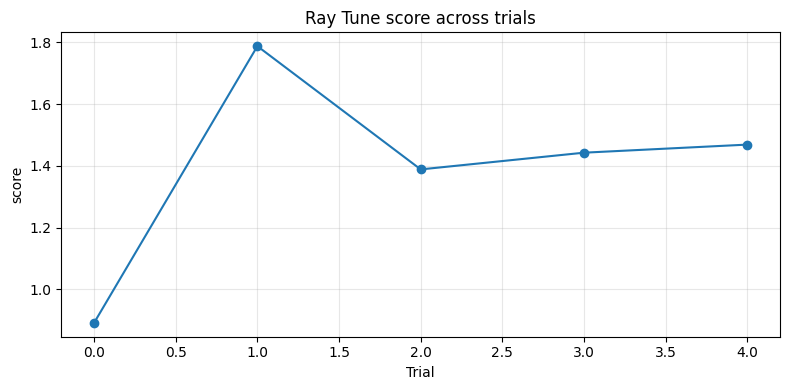

In [24]:
best_config = tune_results.get_best_result().config
print("Best configuration:", best_config)

df = tune_results.get_dataframe()
display(df)

df_sorted = df.reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(df_sorted.index.to_numpy(), df_sorted["score"].to_numpy(), marker="o")
plt.xlabel("Trial")
plt.ylabel("score")
plt.title("Ray Tune score across trials")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation

In [32]:

graphs_0 = [
    train_generator(
        cls_idx=0, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

graphs_1 = [
    train_generator(
        cls_idx=1, 
        max_nodes=config['tune']['max_nodes'], 
        iters_per_sample=config['train']['iters_per_sample'], 
        data=data, 
        mean_embeds=mean_embeds, 
        explainee=explainee, 
        ged_model=model, 
        w_pred  = float(best_config["pred_weight"]), 
        w_embed = float(best_config["embed_weight"]),
        w_ged   = float(best_config["ged_weight"]), 
        w_mcs   = float(best_config["mcs_weight"]),
        w_spec  = float(best_config["spectral_weight"]),
        w_wl    = float(best_config["wl_weight"]),
        use_omega = bool(best_config["use_omega"])
    ) for _ in range(config['train']['samples_per_trial'])
]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

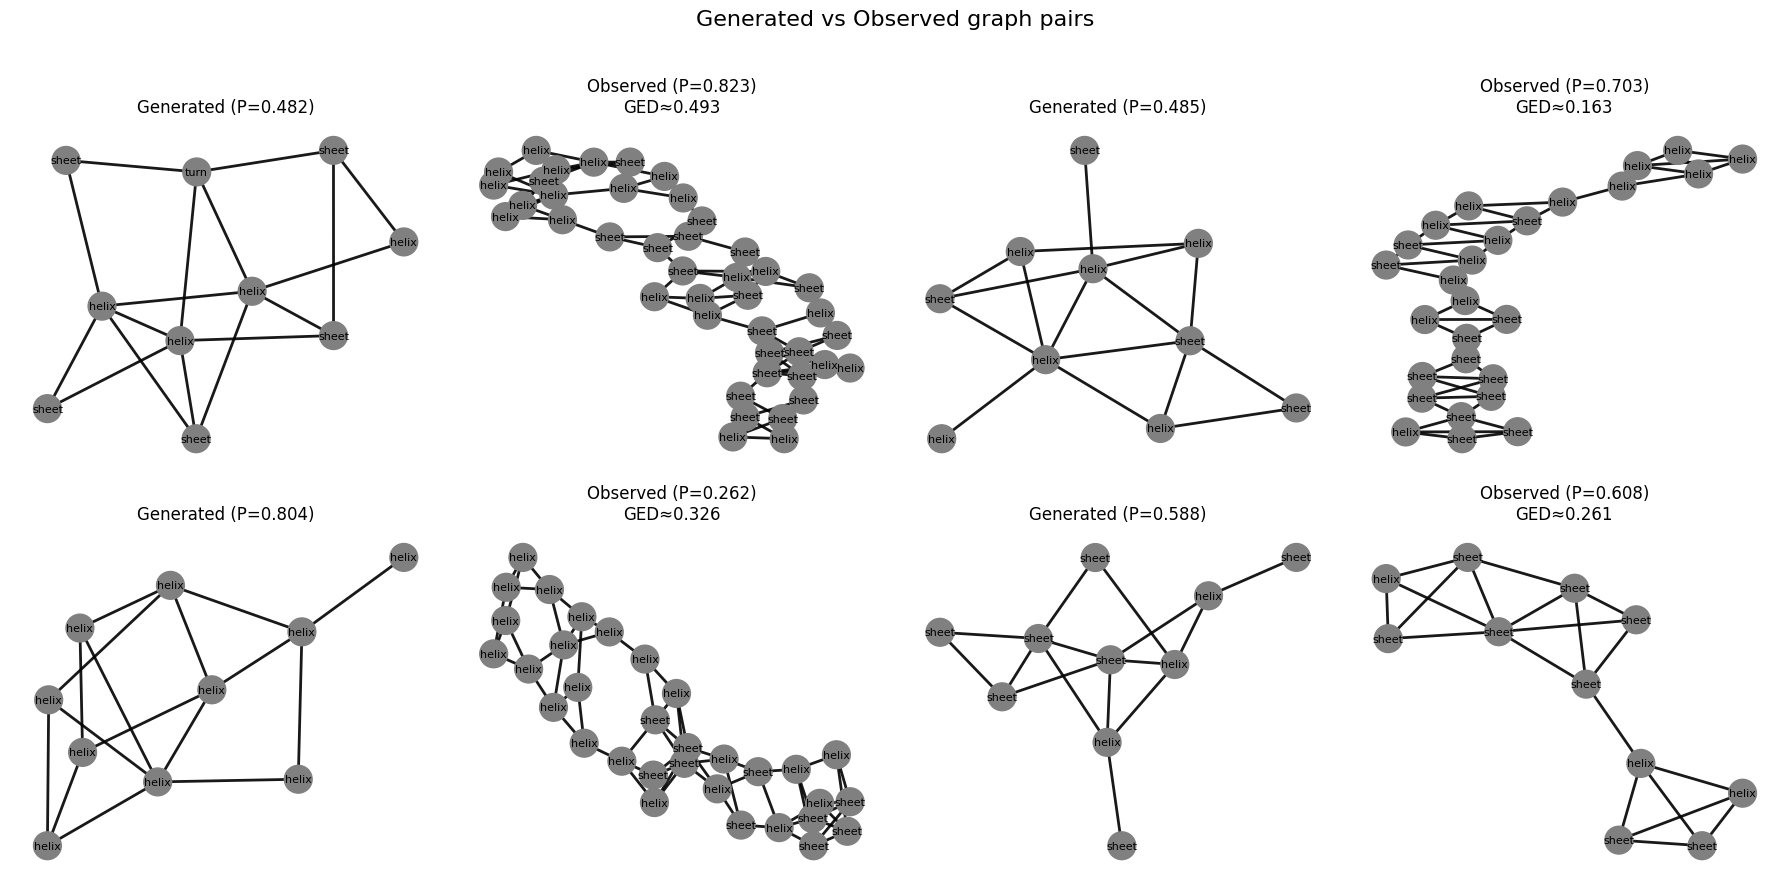

In [33]:
import new_src.utils
importlib.reload(new_src.utils)

from new_src.utils import eval_plot 

eval_plot(
    explainee, 
    graphs_0, 
    graphs_1, 
    obs_graphs_0=cls_split[0], 
    obs_graphs_1=cls_split[1],
    ged_model=model, 
    dataset=data,
    layout="kamada"
)